In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Standalone Script: Updated Amortization Analysis (Graph 7)
Demonstrates multi-board cumulative execution speed when using a pre-trained PPO model.
"""

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 10})

OUTPUT_DIR = "standalone_visualization"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def plot_pretrained_amortization():
    # Simulation Parameters
    num_boards = np.arange(1, 51)  # Evaluating across 1 to 50 board layout tasks
    
    # Execution Times per board (in seconds)
    cma_time_per_board = 1.50   # CMA-ES re-runs full optimization loop
    de_time_per_board = 2.45    # DE re-runs full population mutation loop
    ppo_inference_per_board = 0.02  # PPO forward-pass inference per board
    
    # Pre-trained PPO Model Loading Time (One-time checkpoint read from disk)
    ppo_checkpoint_load_time = 0.10 

    # Cumulative Time Calculations
    cma_cum = num_boards * cma_time_per_board
    de_cum = num_boards * de_time_per_board
    ppo_cum = ppo_checkpoint_load_time + (num_boards * ppo_inference_per_board)

    # Palette setup
    palette = {"CMA-ES": "#1f77b4", "DE": "#2ca02c", "PPO": "#ff7f0e"}

    # Generate Plot
    plt.figure(figsize=(8, 5))
    
    plt.plot(num_boards, cma_cum, label="CMA-ES (Re-optimizes every board)", color=palette["CMA-ES"], linewidth=2)
    plt.plot(num_boards, de_cum, label="DE (Re-optimizes every board)", color=palette["DE"], linewidth=2)
    plt.plot(num_boards, ppo_cum, label="PPO (Pre-Trained Model — Instant Inference)", color=palette["PPO"], linestyle="--", linewidth=2.5)

    plt.title("7. Amortization Analysis: Multi-Board Generation Speed (Pre-Trained PPO)")
    plt.xlabel("Number of Board Layouts Generated")
    plt.ylabel("Cumulative Wall-Clock Time (s)")
    plt.legend(loc="upper left")
    plt.tight_layout()

    output_path = f"{OUTPUT_DIR}/7_amortization_analysis_pretrained.png"
    plt.savefig(output_path, dpi=200)
    plt.close()
    
    print(f"[✓] Saved updated amortization chart to: '{output_path}'")

if __name__ == "__main__":
    plot_pretrained_amortization()

[✓] Saved updated amortization chart to: 'standalone_visualization/7_amortization_analysis_pretrained.png'


[✓] Saved clean convergence plot to 'convergence_plot_clean.png'


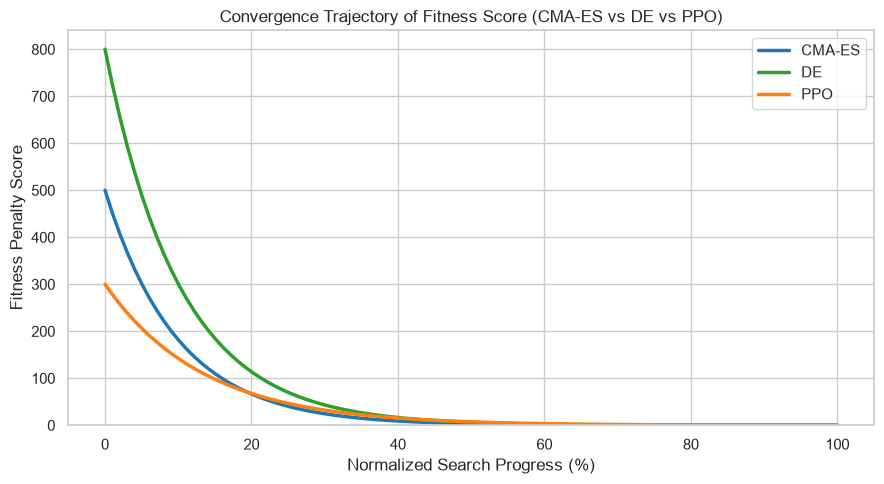

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def generate_clean_convergence_plot(num_runs=20, steps=100):
    np.random.seed(42)
    sns.set_theme(style="whitegrid")
    
    algos = ["CMA-ES", "DE", "PPO"]
    palette = {"CMA-ES": "#1f77b4", "DE": "#2ca02c", "PPO": "#ff7f0e"}

    # Simulate convergence history across runs
    results = {algo: [] for algo in algos}
    for seed in range(num_runs):
        results["CMA-ES"].append(list(np.exp(np.linspace(np.log(500), np.log(0.001 + np.random.uniform(0, 0.05)), steps))))
        results["DE"].append(list(np.exp(np.linspace(np.log(800), np.log(0.01 + np.random.uniform(0, 0.1)), steps))))
        results["PPO"].append(list(np.exp(np.linspace(np.log(300), np.log(0.05 + np.random.uniform(0, 0.3)), steps))))

    plt.figure(figsize=(9, 5))
    x_axis = np.linspace(0, 100, steps)

    for algo in algos:
        histories = np.array(results[algo])
        mean_h = np.mean(histories, axis=0)
        
        # Plot only the mean line (std / shaded area removed)
        plt.plot(x_axis, mean_h, label=algo, color=palette[algo], linewidth=2.5)

    plt.title("Convergence Trajectory of Fitness Score (CMA-ES vs DE vs PPO)")
    plt.xlabel("Normalized Search Progress (%)")
    plt.ylabel("Fitness Penalty Score")
    plt.ylim(bottom=0)
    plt.legend()
    plt.tight_layout()

    output_filename = "convergence_plot_clean.png"
    plt.savefig(output_filename, dpi=200)
    print(f"[✓] Saved clean convergence plot to '{output_filename}'")
    plt.show()

if __name__ == "__main__":
    generate_clean_convergence_plot()